# SmartSegment Auto

Optimisation de la stratégie marketing de l'entreprise par segmentation client.

dataset : https://www.kaggle.com/datasets/vetrirah/customer

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

from sklearn.pipeline import Pipeline

from sklearn.model_selection import train_test_split
from sklearn.ensemble import HistGradientBoostingClassifier

from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

import joblib

In [3]:
df = pd.read_csv('./data/Train.csv')

df.head()

,ID,Gender,Ever_Married,Age,Graduated,Profession,Work_Experience,Spending_Score,Family_Size,Var_1,Segmentation
0,462809,Male,No,22,No,Healthcare,1.0,Low,4.0,Cat_4,D
1,462643,Female,Yes,38,Yes,Engineer,NaN,Average,3.0,Cat_4,A
2,466315,Female,Yes,67,Yes,Engineer,1.0,Low,1.0,Cat_6,B
3,461735,Male,Yes,67,Yes,Lawyer,0.0,High,2.0,Cat_6,B
4,462669,Female,Yes,40,Yes,Entertainment,NaN,High,6.0,Cat_6,A


Affichage des 5 premières lignes du dataset.

Nous avons les variables suivantes :
- ID : ID de l'application source, ne sera pas utilisé ;
- Gender : le genre de la personne : Homme ou femme ;
- Ever_Married : La personne a t elle déja été mariée ;
- Age : l'age ;
- Graduated : la personne est-elle diplomée ;
- Work_Experience : nombre d'années d'experience au travail ;
- Spending_Score : score de dépense de l'utilisateur
- Family_Size : taille de la famille ;
- Var_1 : **une catégorie anonymisée** pour la conformité RGPD / CNIL ;
- Segmentation : notre **label** : le segment de l'utilisateur (A, B, C, D). C'est ceci qu'il faudra prédire.

## Structure des données

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8068 entries, 0 to 8067
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ID               8068 non-null   int64  
 1   Gender           8068 non-null   str    
 2   Ever_Married     7928 non-null   str    
 3   Age              8068 non-null   int64  
 4   Graduated        7990 non-null   str    
 5   Profession       7944 non-null   str    
 6   Work_Experience  7239 non-null   float64
 7   Spending_Score   8068 non-null   str    
 8   Family_Size      7733 non-null   float64
 9   Var_1            7992 non-null   str    
 10  Segmentation     8068 non-null   str    
dtypes: float64(2), int64(2), str(7)
memory usage: 693.5 KB


Nous avons 8067 lignes dans ce dataset.

- les variables `Age`, `Work_Experience` et `Family_Size` sont des variables quantitative (numérique) ;
- les variables `Gender`, `Graduated`, `Profession`, `Spending_Score` et `Var_1` sont des variables qualitatives (des catégories).
- la variable `Segmentation` est notre label, 4 catégories : A, B, C et D.

In [5]:
# suppression de la colonne ID, renommage des colonnes en minuscule

df = df.drop(columns="ID").rename(
    columns={
        "Gender": "gender",
        "Ever_Married": "ever_married",
        "Age": "age",
        "Graduated": "graduated",
        "Profession": "profession",
        "Work_Experience": "work_experience",
        "Spending_Score": "spending_score",
        "Family_Size": "family_size",
        "Var_1": "var_1",
        "Segmentation": "segmentation",
    }
).copy()

df.sample(n=5)

,gender,ever_married,age,graduated,profession,work_experience,spending_score,family_size,var_1,segmentation
5270,Female,Yes,47,Yes,Entertainment,3.0,Average,2.0,Cat_6,B
1403,Female,Yes,63,No,Engineer,4.0,Average,8.0,Cat_4,D
6408,Female,No,26,Yes,Healthcare,0.0,Low,3.0,Cat_6,D
1825,Female,No,39,Yes,Artist,0.0,Low,1.0,Cat_6,A
2202,Female,No,41,No,Marketing,1.0,Low,NaN,Cat_3,D


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8068 entries, 0 to 8067
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   gender           8068 non-null   str    
 1   ever_married     7928 non-null   str    
 2   age              8068 non-null   int64  
 3   graduated        7990 non-null   str    
 4   profession       7944 non-null   str    
 5   work_experience  7239 non-null   float64
 6   spending_score   8068 non-null   str    
 7   family_size      7733 non-null   float64
 8   var_1            7992 non-null   str    
 9   segmentation     8068 non-null   str    
dtypes: float64(2), int64(1), str(7)
memory usage: 630.4 KB


Nous avons des données manquantes, nous les traiterons ultérieurement.

Regardons les répartitions de données :

<Axes: xlabel='gender'>

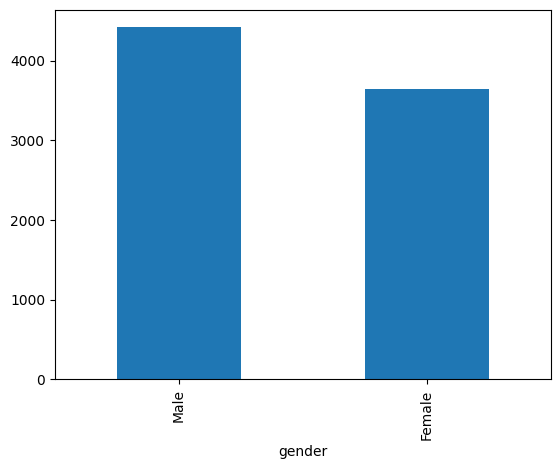

In [7]:
df['gender'].value_counts().plot.bar()

<Axes: xlabel='ever_married'>

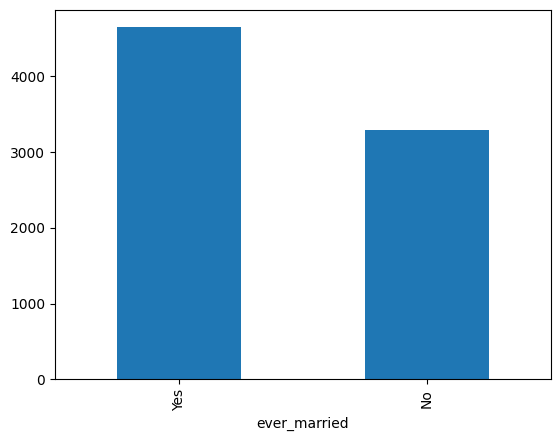

In [8]:
df['ever_married'].value_counts().plot.bar()

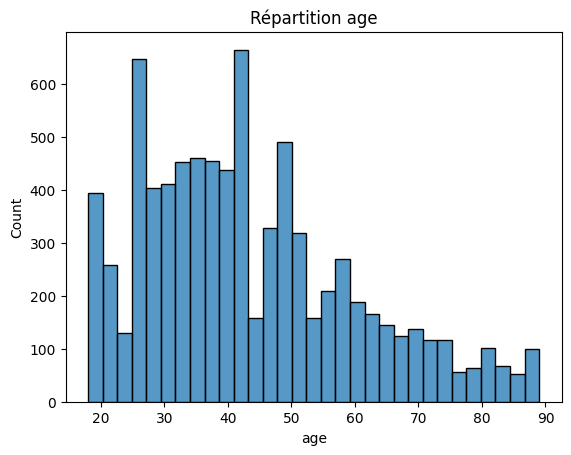

In [9]:
plt.figure()
sns.histplot(data=df["age"])
plt.title(f"Répartition age")
plt.show()

<Axes: xlabel='graduated'>

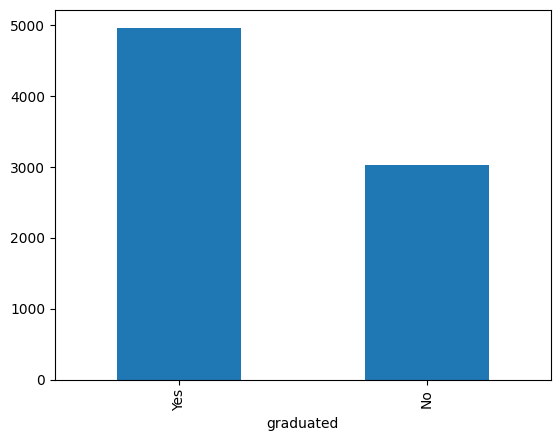

In [10]:
df['graduated'].value_counts().plot.bar()

<Axes: xlabel='profession'>

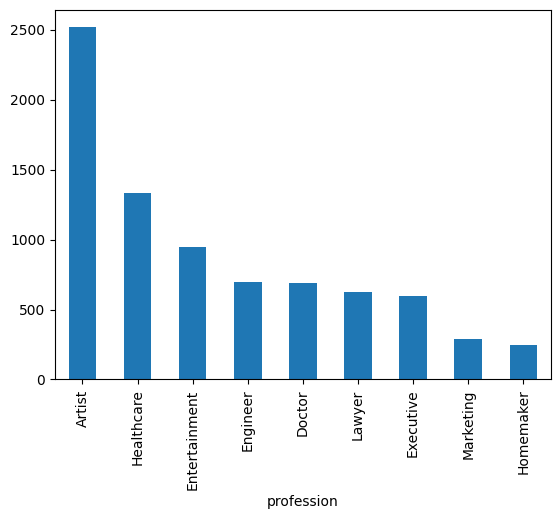

In [11]:
df['profession'].value_counts().plot.bar()

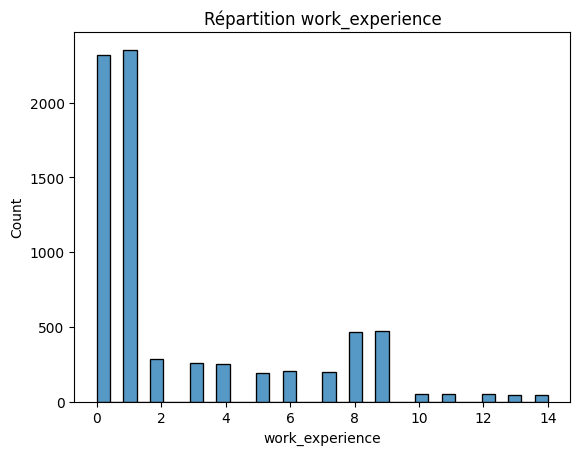

In [12]:
plt.figure()
sns.histplot(data=df["work_experience"])
plt.title(f"Répartition work_experience")
plt.show()

<Axes: xlabel='spending_score'>

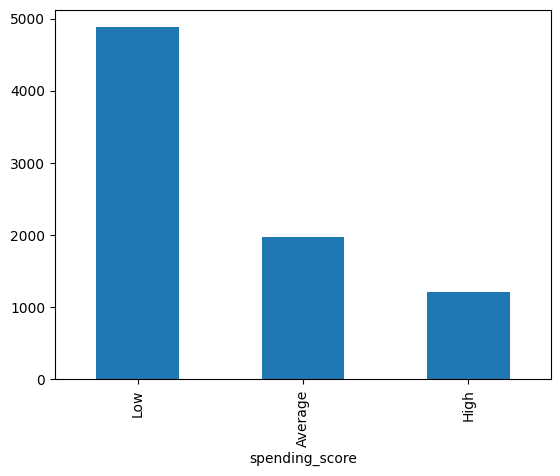

In [13]:
df['spending_score'].value_counts().plot.bar()

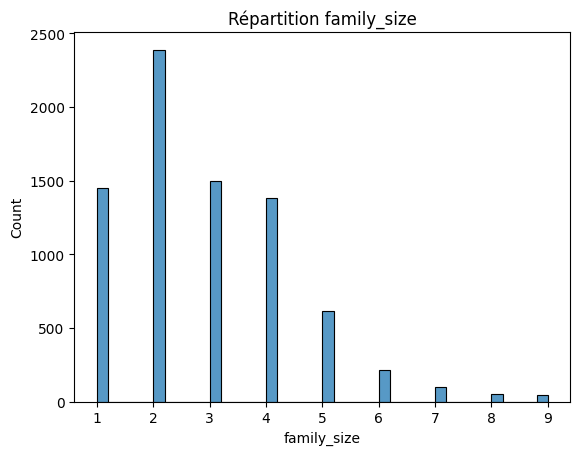

In [14]:
plt.figure()
sns.histplot(data=df["family_size"])
plt.title(f"Répartition family_size")
plt.show()

<Axes: xlabel='var_1'>

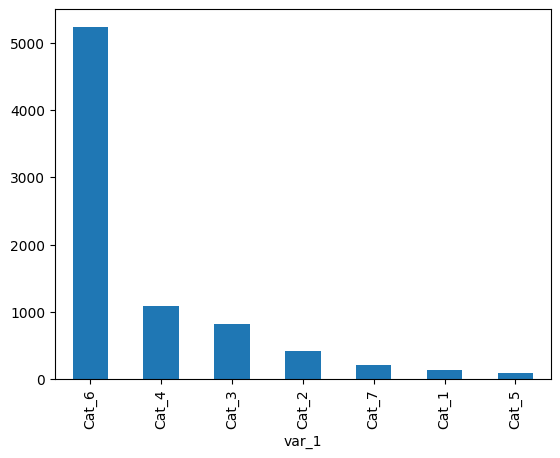

In [15]:
df['var_1'].value_counts().plot.bar()

<Axes: xlabel='segmentation'>

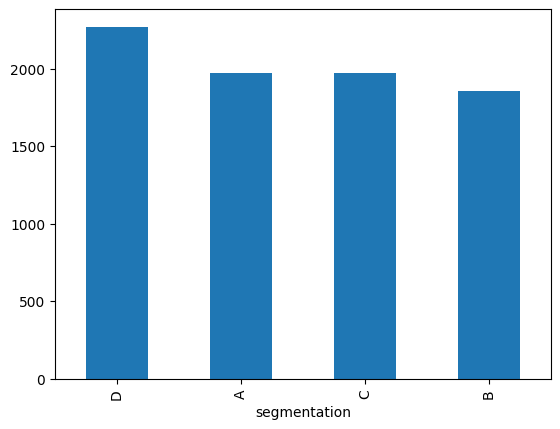

In [16]:
df['segmentation'].value_counts().plot.bar()

In [17]:
df.describe(include="all")

,gender,ever_married,age,graduated,profession,work_experience,spending_score,family_size,var_1,segmentation
count,8068,7928,8068.000000,7990,7944,7239.000000,8068,7733.000000,7992,8068
unique,2,2,NaN,2,9,NaN,3,NaN,7,4
top,Male,Yes,NaN,Yes,Artist,NaN,Low,NaN,Cat_6,D
freq,4417,4643,NaN,4968,2516,NaN,4878,NaN,5238,2268
mean,NaN,NaN,43.466906,NaN,NaN,2.641663,NaN,2.850123,NaN,NaN
std,NaN,NaN,16.711696,NaN,NaN,3.406763,NaN,1.531413,NaN,NaN
min,NaN,NaN,18.000000,NaN,NaN,0.000000,NaN,1.000000,NaN,NaN
25%,NaN,NaN,30.000000,NaN,NaN,0.000000,NaN,2.000000,NaN,NaN
50%,NaN,NaN,40.000000,NaN,NaN,1.000000,NaN,3.000000,NaN,NaN
75%,NaN,NaN,53.000000,NaN,NaN,4.000000,NaN,4.000000,NaN,NaN


## Traitement des valeurs manquantes

In [18]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8068 entries, 0 to 8067
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   gender           8068 non-null   str    
 1   ever_married     7928 non-null   str    
 2   age              8068 non-null   int64  
 3   graduated        7990 non-null   str    
 4   profession       7944 non-null   str    
 5   work_experience  7239 non-null   float64
 6   spending_score   8068 non-null   str    
 7   family_size      7733 non-null   float64
 8   var_1            7992 non-null   str    
 9   segmentation     8068 non-null   str    
dtypes: float64(2), int64(1), str(7)
memory usage: 630.4 KB


In [19]:
df.isnull().sum()

gender               0
ever_married       140
age                  0
graduated           78
profession         124
work_experience    829
spending_score       0
family_size        335
var_1               76
segmentation         0
dtype: int64

Pour nos données catégorielles, nous remplaçons les valeurs manquantes par la valeur la plus fréquente

In [20]:
for col in ["ever_married", "graduated", "profession", "var_1"]:
    df.loc[:, col] = df[col].fillna(df[col].mode()[0])

Pour les données quantitatives, nous remplaçons par la médiane

In [21]:
df.loc[:, "work_experience"] = df["work_experience"].fillna(df["work_experience"].median())
df.loc[:, "family_size"] = df["family_size"].fillna(df["family_size"].median())

In [22]:
df.isnull().sum()

gender             0
ever_married       0
age                0
graduated          0
profession         0
work_experience    0
spending_score     0
family_size        0
var_1              0
segmentation       0
dtype: int64

Nous en avons terminé avec les données manquantes.

## Détection des problèmes dans les données

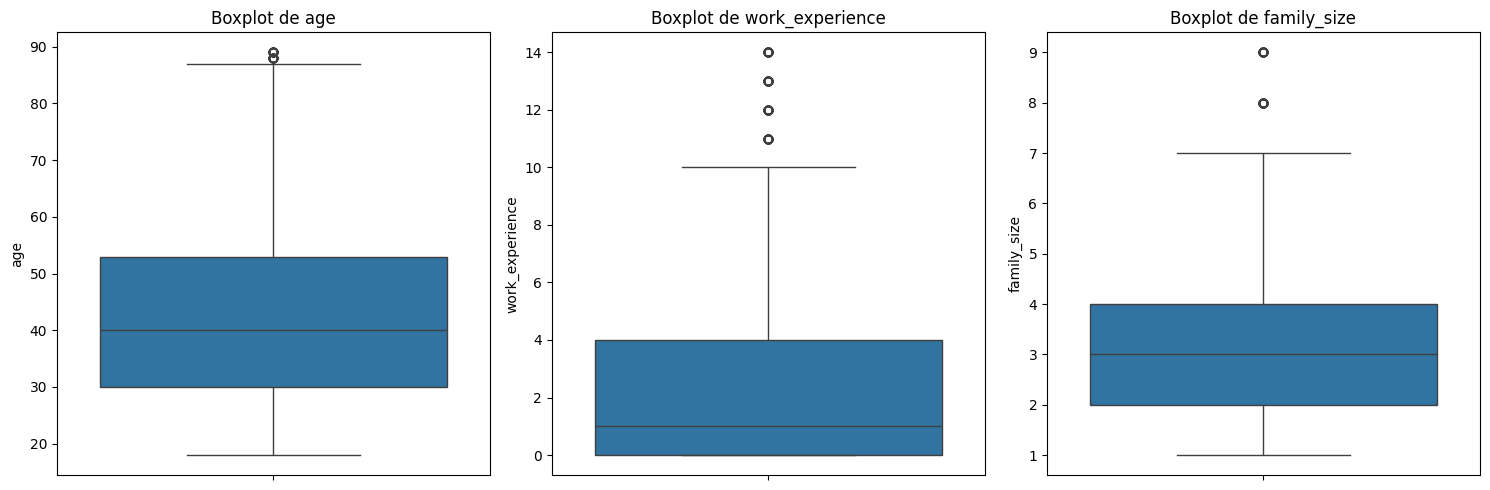

In [23]:
variables_quantitatives = ["age", "work_experience", "family_size"]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, var in enumerate(variables_quantitatives):
    sns.boxplot(data=df, y=var, ax=axes[i])
    axes[i].set_title(f"Boxplot de {var}")

plt.tight_layout()
plt.show()

Nous avons des **outliers**, des données aberrentes. Nous allons les traiter en nous basant sur l'écart inter quartil (IQR). Dès que la donnée est supérieure à Q3 + (1.5 * IQR), nous remplaçons par cette limite. De même pour la partie limite basse Q1 - (1.5 * IQR).

In [24]:
for variable in variables_quantitatives:

    # calcul IQR    
    Q1 = df[variable].quantile(0.25)
    Q3 = df[variable].quantile(0.75)
    IQR = Q3 - Q1

    # limites basse / haute
    limite_basse = Q1 - 1.5 * IQR
    limite_haute = Q3 + 1.5 * IQR

    df[variable] = np.where(df[variable] < limite_basse, limite_basse, df[variable])
    df[variable] = np.where(df[variable] > limite_haute, limite_haute, df[variable])

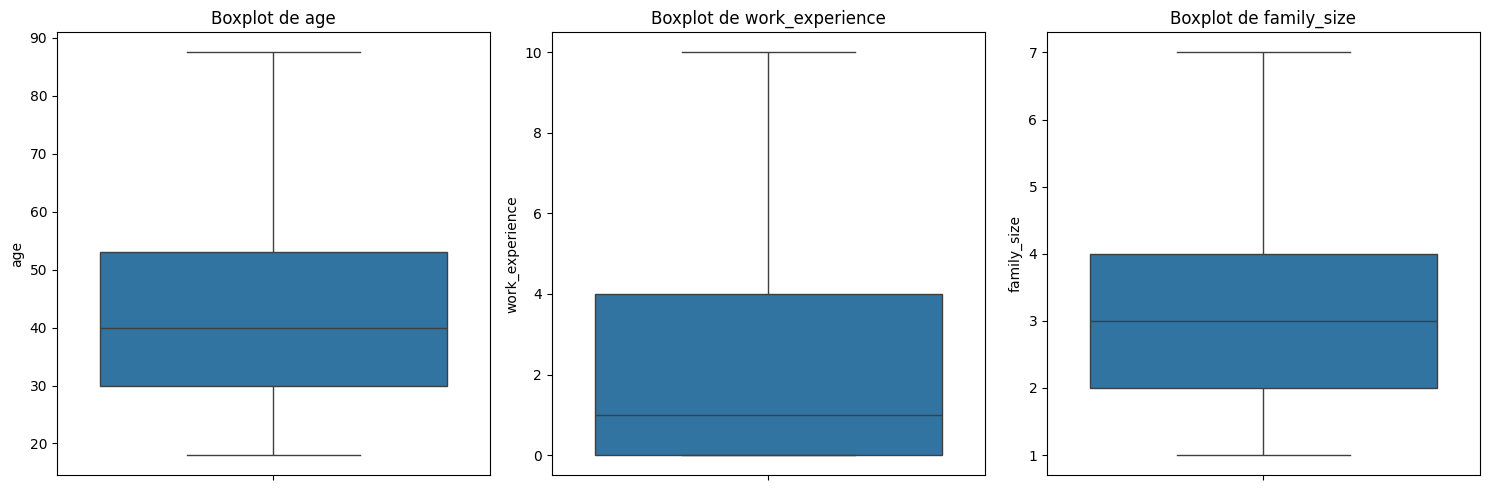

In [25]:
variables_quantitatives = ["age", "work_experience", "family_size"]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, var in enumerate(variables_quantitatives):
    sns.boxplot(data=df, y=var, ax=axes[i])
    axes[i].set_title(f"Boxplot de {var}")

plt.tight_layout()
plt.show()

Nous avons traité les outliers.

## Analyse et corrélations

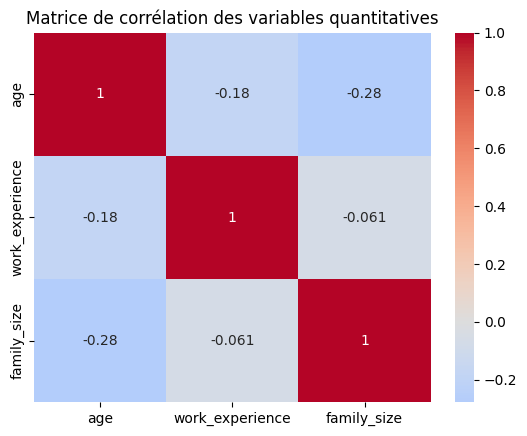

In [26]:
plt.figure()
sns.heatmap(df[variables_quantitatives].corr(), annot=True, cmap="coolwarm", center=0)
plt.title("Matrice de corrélation des variables quantitatives")
plt.show()

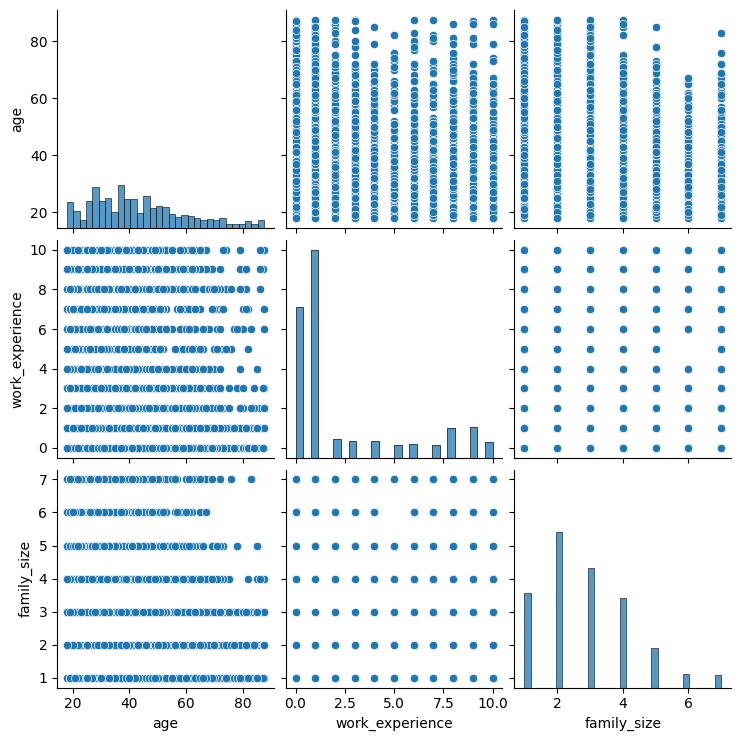

In [27]:
sns.pairplot(df[variables_quantitatives])
plt.show()

il ne semble pas y avoir de corrélations entre nos variables quantitatives.

## Modélisation

### Choix des variables

nous allons selectionner les variables suivantes pour nos modèles et leurs appliquer le traitement correspondant :

| variable        | commentaire                                               |
| --------------- | --------------------------------------------------------- |
| age             | Feature, quantitative, à normaliser avec `StandardScaler` |
| work_experience | Feature, quantitative, à normaliser avec `StandardScaler` |
| family_size     | Feature, quantitative, à normaliser avec `StandardScaler` |
| gender          | Feature. Traitement en one hot encoding (2 modalités)     |
| ever_married    | Feature. Traitement en one hot encoding (2 modalités)     |
| graduated       | Feature. Traitement en one hot encoding (2 modalités)     |
| profession      | Feature. Traitement en one hot encoding (9 modalités)     |
| spending_score  | Feature. Traitement en one hot encoding (3 modalités)     |
| var_1           | Feature. Traitement en one hot encoding (7 modalités)     |

Cela fera donc **28 dimensions suite au one hot encoding.**

In [28]:
variables_qualitatives = ["gender", "ever_married", "graduated", "profession", "spending_score", "var_1"]

variables_quant_qual = variables_quantitatives + variables_qualitatives

df = df[variables_quant_qual + ["segmentation"]]

df.sample(n=5)

,age,work_experience,family_size,gender,ever_married,graduated,profession,spending_score,var_1,segmentation
6414,26.0,0.0,4.0,Male,No,No,Healthcare,Low,Cat_3,C
5162,85.0,0.0,2.0,Male,Yes,Yes,Executive,High,Cat_6,C
5231,23.0,0.0,3.0,Female,No,No,Healthcare,Low,Cat_6,D
5122,49.0,1.0,4.0,Male,Yes,Yes,Artist,Average,Cat_6,C
1182,35.0,8.0,3.0,Male,Yes,Yes,Entertainment,Average,Cat_2,D


### Traitement des variables

- normalisation `StandardScaler()` pour les variables quantitatives
- One hot enconding `OneHotEncoder()` pour les variables qualitatives

In [29]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), variables_quantitatives),
        (
            "cat",
            OneHotEncoder(drop=None, handle_unknown="ignore"),
            variables_qualitatives,
        ),
    ],
    remainder="drop",
)

In [30]:
X = df[variables_quant_qual]

y = df["segmentation"]

In [31]:
X_encoded = preprocessor.fit_transform(X)

# nouveaux nom de colonnes

columns_one_hot = preprocessor.named_transformers_["cat"].get_feature_names_out(variables_qualitatives)

columns = variables_quantitatives + list(columns_one_hot)

df_features = pd.DataFrame(X_encoded, columns=columns)
df_features


,age,work_experience,family_size,gender_Female,gender_Male,ever_married_No,ever_married_Yes,graduated_No,graduated_Yes,profession_Artist,...,spending_score_Average,spending_score_High,spending_score_Low,var_1_Cat_1,var_1_Cat_2,var_1_Cat_3,var_1_Cat_4,var_1_Cat_5,var_1_Cat_6,var_1_Cat_7
0,-1.285917,-0.456344,0.805152,0.0,1.0,1.0,0.0,1.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1,-0.327084,-0.456344,0.111509,1.0,0.0,0.0,1.0,0.0,1.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2,1.410800,-0.456344,-1.275777,1.0,0.0,0.0,1.0,0.0,1.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3,1.410800,-0.778742,-0.582134,0.0,1.0,0.0,1.0,0.0,1.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,-0.207230,-0.456344,2.192437,1.0,0.0,0.0,1.0,0.0,1.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8063,-1.285917,-0.778742,2.886080,0.0,1.0,1.0,0.0,1.0,0.0,1.0,...,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
8064,-0.506866,0.188452,0.805152,0.0,1.0,1.0,0.0,1.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
8065,-0.626720,-0.456344,-1.275777,1.0,0.0,1.0,0.0,0.0,1.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
8066,-0.986282,-0.456344,0.805152,1.0,0.0,1.0,0.0,0.0,1.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


### DataFrame final

In [32]:
df_final = pd.concat([df_features, y], axis=1)
df_final

,age,work_experience,family_size,gender_Female,gender_Male,ever_married_No,ever_married_Yes,graduated_No,graduated_Yes,profession_Artist,...,spending_score_High,spending_score_Low,var_1_Cat_1,var_1_Cat_2,var_1_Cat_3,var_1_Cat_4,var_1_Cat_5,var_1_Cat_6,var_1_Cat_7,segmentation
0,-1.285917,-0.456344,0.805152,0.0,1.0,1.0,0.0,1.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,D
1,-0.327084,-0.456344,0.111509,1.0,0.0,0.0,1.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,A
2,1.410800,-0.456344,-1.275777,1.0,0.0,0.0,1.0,0.0,1.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,B
3,1.410800,-0.778742,-0.582134,0.0,1.0,0.0,1.0,0.0,1.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,B
4,-0.207230,-0.456344,2.192437,1.0,0.0,0.0,1.0,0.0,1.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,A
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8063,-1.285917,-0.778742,2.886080,0.0,1.0,1.0,0.0,1.0,0.0,1.0,...,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,D
8064,-0.506866,0.188452,0.805152,0.0,1.0,1.0,0.0,1.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,D
8065,-0.626720,-0.456344,-1.275777,1.0,0.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,D
8066,-0.986282,-0.456344,0.805152,1.0,0.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,B


## Modèle non supervisé

Nous allons appliquer l'algorithme KMeans. C'est un algorithme non supervisé très performant même avec beaucoup de dimensions.

Cela aboutira à un clustering, qui nous permettras de comprendre les "profils" de consommateurs.

Pour ce clustering, nous n'allons pas utiliser la variable `segmentation` (puisque cela n'a pas de sens en non supervisé)

In [33]:
df_features_only = df_final.drop(columns="segmentation")

df_features_only

,age,work_experience,family_size,gender_Female,gender_Male,ever_married_No,ever_married_Yes,graduated_No,graduated_Yes,profession_Artist,...,spending_score_Average,spending_score_High,spending_score_Low,var_1_Cat_1,var_1_Cat_2,var_1_Cat_3,var_1_Cat_4,var_1_Cat_5,var_1_Cat_6,var_1_Cat_7
0,-1.285917,-0.456344,0.805152,0.0,1.0,1.0,0.0,1.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1,-0.327084,-0.456344,0.111509,1.0,0.0,0.0,1.0,0.0,1.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2,1.410800,-0.456344,-1.275777,1.0,0.0,0.0,1.0,0.0,1.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3,1.410800,-0.778742,-0.582134,0.0,1.0,0.0,1.0,0.0,1.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,-0.207230,-0.456344,2.192437,1.0,0.0,0.0,1.0,0.0,1.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8063,-1.285917,-0.778742,2.886080,0.0,1.0,1.0,0.0,1.0,0.0,1.0,...,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
8064,-0.506866,0.188452,0.805152,0.0,1.0,1.0,0.0,1.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
8065,-0.626720,-0.456344,-1.275777,1.0,0.0,1.0,0.0,0.0,1.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
8066,-0.986282,-0.456344,0.805152,1.0,0.0,1.0,0.0,0.0,1.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


Kmean n_clusters = 2
Kmean n_clusters = 3
Kmean n_clusters = 4
Kmean n_clusters = 5
Kmean n_clusters = 6
Kmean n_clusters = 7
Kmean n_clusters = 8
Kmean n_clusters = 9


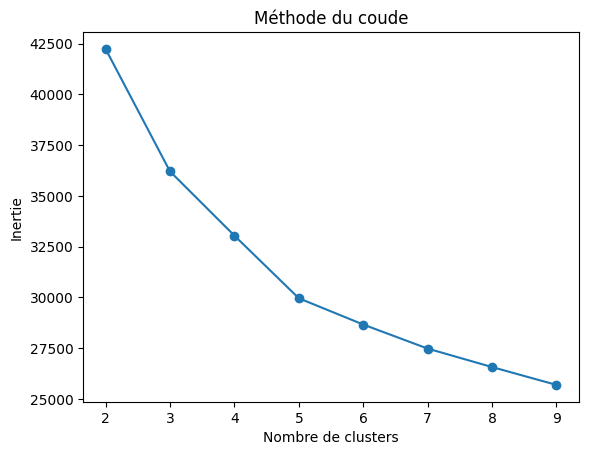

In [34]:
# nous allons appliquer la méthode du coude, pour trouver le nombre de cluster optimal (celui qui réduit l'intertie sans avoir un nombre trop élevé de clusters)

n_clusters_range = list(range(2, 10))
inertias = []
for k in n_clusters_range:
    print(f"Kmean n_clusters = {k}")
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(df_features_only)
    inertias.append(kmeans.inertia_)

plt.plot(n_clusters_range, inertias, marker="o")
plt.title("Méthode du coude")
plt.xlabel("Nombre de clusters")
plt.ylabel("Inertie")
plt.show()

D'après la méthode du coude, 5 clusters semblent pertinents.

In [35]:
n_clusters = 5

In [36]:
kmeans = KMeans(n_clusters=n_clusters, random_state=17, n_init=10)
clusters = kmeans.fit_predict(df_features_only)

df_kmeans = df_final.copy()
df_kmeans["cluster"] = clusters

df_kmeans

,age,work_experience,family_size,gender_Female,gender_Male,ever_married_No,ever_married_Yes,graduated_No,graduated_Yes,profession_Artist,...,spending_score_Low,var_1_Cat_1,var_1_Cat_2,var_1_Cat_3,var_1_Cat_4,var_1_Cat_5,var_1_Cat_6,var_1_Cat_7,segmentation,cluster
0,-1.285917,-0.456344,0.805152,0.0,1.0,1.0,0.0,1.0,0.0,0.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,D,1
1,-0.327084,-0.456344,0.111509,1.0,0.0,0.0,1.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,A,2
2,1.410800,-0.456344,-1.275777,1.0,0.0,0.0,1.0,0.0,1.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,B,0
3,1.410800,-0.778742,-0.582134,0.0,1.0,0.0,1.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,B,0
4,-0.207230,-0.456344,2.192437,1.0,0.0,0.0,1.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,A,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8063,-1.285917,-0.778742,2.886080,0.0,1.0,1.0,0.0,1.0,0.0,1.0,...,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,D,1
8064,-0.506866,0.188452,0.805152,0.0,1.0,1.0,0.0,1.0,0.0,0.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,D,1
8065,-0.626720,-0.456344,-1.275777,1.0,0.0,1.0,0.0,0.0,1.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,D,4
8066,-0.986282,-0.456344,0.805152,1.0,0.0,1.0,0.0,0.0,1.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,B,1


### Visualisation des clusters

Nous allons réduire les dimensions avec une PCA (Principal component analysis) afin d'afficher de manière graphique le résultat du clustering.

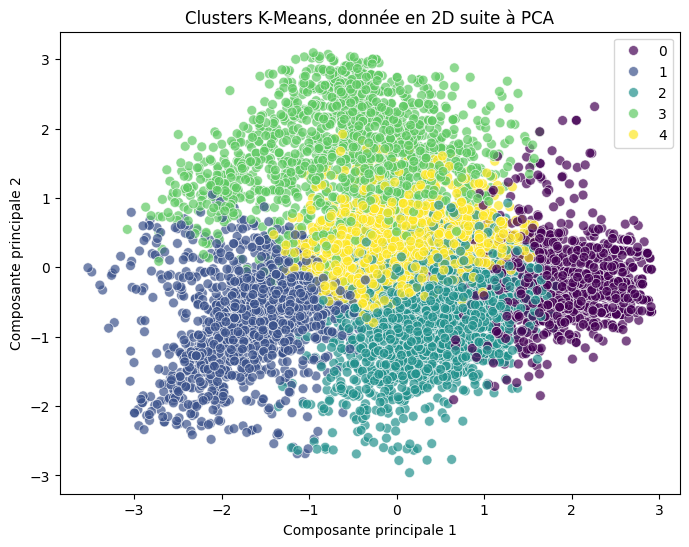

In [37]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(df_features_only)

plt.figure(figsize=(8, 6))
sns.scatterplot(
    x=X_pca[:, 0], y=X_pca[:, 1], hue=clusters, palette="viridis", s=50, alpha=0.7
)
plt.title(f"Clusters K-Means, donnée en 2D suite à PCA")
plt.xlabel("Composante principale 1")
plt.ylabel("Composante principale 2")
plt.show()

Analysons maintenant si les clusters sont porteurs d'information par rapport à notre variable `segmentation` :

In [38]:
# Tableau croisé cluster vs segmentation

cross_tab = pd.crosstab(clusters, y, normalize="index")
print(cross_tab)

segmentation         A         B         C         D
row_0                                               
0             0.278367  0.284898  0.276735  0.160000
1             0.124447  0.092862  0.135186  0.647505
2             0.188731  0.309208  0.416858  0.085204
3             0.287433  0.197861  0.201203  0.313503
4             0.374447  0.247312  0.130297  0.247944


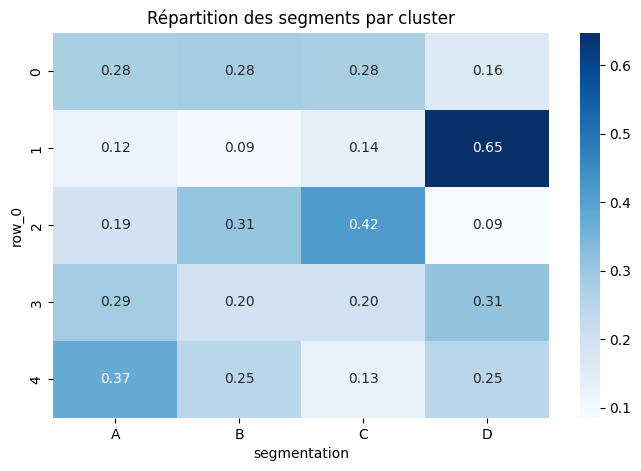

In [39]:
plt.figure(figsize=(8, 5))
sns.heatmap(cross_tab, annot=True, cmap="Blues", fmt=".2f")
plt.title("Répartition des segments par cluster")
plt.show()

Non, au sein de nos clusters nous n'avons pas plus d'informations sur la segmentation du consommateur.

C'est un comportement normal puisque ce n'est pas le but d'un algorithme non supervisé tel que le KMean.

Mais comme nous avons des données labelisées, nous allons pouvoir entraîner un modèle supervisé, qui lui devrait nous aider à prédire le segment de l'utilisateur.

### Sauvegarde du modèle non supervisé

Avant de passer au modèle supervisé, sous allons sauvegarder le **modèle non supervisé** au format `pickle`. Nous allons d'abord regrouper tout le traitement dans un unique traitement `pipeline`.

In [40]:
# on regroupe tout le traitement dans un pipeline

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), variables_quantitatives),
        (
            "cat",
            OneHotEncoder(drop=None, handle_unknown="ignore"),
            variables_qualitatives,
        ),
    ],
    remainder="drop",
)

kmeans = KMeans(n_clusters=n_clusters, random_state=17, n_init=10)

pipeline_non_supervise = Pipeline(
    [
        ("preprocessor", preprocessor),
        ("kmeans", kmeans),
    ]
)

# application sur les données

X = df[variables_quantitatives + variables_qualitatives]

pipeline_non_supervise.fit(X)

# test

df_test = df[variables_quantitatives + variables_qualitatives + ["segmentation"]]

df_test["cluster"] = pipeline_non_supervise.named_steps["kmeans"].labels_

# analyse

cross_tab = pd.crosstab(df_test["cluster"], y, normalize="index")
print(cross_tab)

segmentation         A         B         C         D
cluster                                             
0             0.278367  0.284898  0.276735  0.160000
1             0.124447  0.092862  0.135186  0.647505
2             0.188731  0.309208  0.416858  0.085204
3             0.287433  0.197861  0.201203  0.313503
4             0.374447  0.247312  0.130297  0.247944


Sauvegarde du modèle

In [41]:
joblib.dump(pipeline_non_supervise, './models/non_supervise.pkl')

['./models/non_supervise.pkl']

## Modèle supervisé

Comme nous avons des données labelisées, un modèle supervisé sera adapté pour prédire le segment des utilisateurs.

Les algorightmes les plus indiqués pour notre cas d'usage sont `RandomForest`, `XGBoost` et `LightGBM`.

| Algorithme   | Adapté pour 8k lignes / 28 dims | Interprétabilité | Rapide      |
|--------------|---------------------------------|------------------|-------------|
| RandomForest | Moyen                           | Très fort        | lent        |
| XGBoost      | Très fort                       | Moyen            | Très rapide |
| LightGBM     | Très fort                       | Fort             | Très rapide |

Nous choisissons `LightGBM` qui coche toute les cases : un algo adapté, rapide, performant et fournissant des résultats interprétables.

L'implémentation proche de `LightGBM` dans `sklearn` est `HistGradientBoostingClassifier` (elle présente les mêmes techniques et avantages)

In [42]:
# données d'entrées

X

,age,work_experience,family_size,gender,ever_married,graduated,profession,spending_score,var_1
0,22.0,1.0,4.0,Male,No,No,Healthcare,Low,Cat_4
1,38.0,1.0,3.0,Female,Yes,Yes,Engineer,Average,Cat_4
2,67.0,1.0,1.0,Female,Yes,Yes,Engineer,Low,Cat_6
3,67.0,0.0,2.0,Male,Yes,Yes,Lawyer,High,Cat_6
4,40.0,1.0,6.0,Female,Yes,Yes,Entertainment,High,Cat_6
...,...,...,...,...,...,...,...,...,...
8063,22.0,0.0,7.0,Male,No,No,Artist,Low,Cat_1
8064,35.0,3.0,4.0,Male,No,No,Executive,Low,Cat_4
8065,33.0,1.0,1.0,Female,No,Yes,Healthcare,Low,Cat_6
8066,27.0,1.0,4.0,Female,No,Yes,Healthcare,Low,Cat_6


In [43]:
# donnée à prédire

y

0       D
1       A
2       B
3       B
4       A
       ..
8063    D
8064    D
8065    D
8066    B
8067    B
Name: segmentation, Length: 8068, dtype: str

On découpe le dataset en deux partie : données d'entraînement et données de test. `stratify` permet de s'assurer de la bonne répartition de la variable `segmentation` dans le découpage. Cela permet d'éviter d'avoir des données de test qu'avec des segments A par exemple.

In [44]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=17,
    stratify=y,
)

Nous allons directement faire un `pipeline` sklearn qui regroupe ce dont nous avons besoin :
- `StandardScaler()` pour nos variables quantitatives ;
- encodage `OneHot` pour nos catégories ;
- modèle `HistGradientBoostingClassifier` (équivalent de `LightGBM`)

In [45]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            variables_quantitatives,
        ),
        (
            "cat",
            OneHotEncoder(drop=None, handle_unknown="ignore"),
            variables_qualitatives,
        ),
    ]
)

# classifier HistGradientBoostingClassifier : équivalent de LightGBM

classifier = HistGradientBoostingClassifier(
    random_state=17,
    class_weight="balanced",
    max_iter=300,
    learning_rate=5e-2,
    max_depth=10,
    min_samples_leaf=20,
)

pipeline_supervise = Pipeline(
    [
        ("preprocessor", preprocessor),
        ("classifier", classifier),
    ]
)

pipeline_supervise.fit(X, y)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

In [46]:
# Évaluer le modèle

y_pred = pipeline_supervise.predict(X_test)
print("Rapport de classification :")
print(classification_report(y_test, y_pred))

Rapport de classification :
              precision    recall  f1-score   support

           A       0.72      0.75      0.73       592
           B       0.70      0.64      0.67       557
           C       0.72      0.74      0.73       591
           D       0.82      0.82      0.82       681

    accuracy                           0.74      2421
   macro avg       0.74      0.74      0.74      2421
weighted avg       0.74      0.74      0.74      2421



In [53]:
y_pred

array(['A', 'C', 'A', ..., 'A', 'D', 'D'], shape=(2421,), dtype=object)

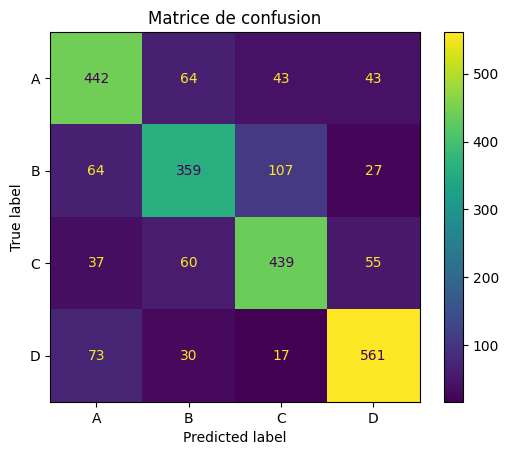

In [47]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=["A", "B", "C", "D"])
plt.title("Matrice de confusion")
plt.show()

## Interprétations des résultats

Le modèle est plutôt performant, il démontre une précision globale de **74%**.

La précision évalue le nombre de vrais positifis parmis tous les cas prédits positifs :

$$
\frac {TP} {TP+FP}
$$

ce qui est interessant dans notre cas : sur 100 prédictions concernant le segment X, 74 seront correctes.

Le recall n'est pas mauvais non plus (sauf pour la classe B).

Le recall évalue le nombre de cas prédits positifs parmis tous les cas positifs :

$$
\frac {TP} {TP+FN}
$$

Exemple : sur 100 clients de la classe D, 82 seront labelisés correctement par l'algorithme.

le `F1 score` est la moyenne harmonique de la `precision` et du `recall`. Il est bon sauf pour la classe B.

L'`accuracy` (français : justesse) est le nombre d'évaluations correctes / le nombre total. La justesse est bonne avec un score de 74%.

### Sauvegarde du modèle supervisé

In [54]:
joblib.dump(pipeline_supervise, './models/supervise.pkl')

['./models/supervise.pkl']

## Calcul des `importances`

Sur certains algorithme il est possible de voir quelles features ont été déterminantes pour appliquer une classe lors de la classification. C'est le cas de notre algorithme `LightGBM`.

In [49]:
from sklearn.inspection import permutation_importance

result = permutation_importance(
    pipeline_supervise,
    X,
    y,
    n_repeats=10,
    random_state=17,
    n_jobs=-1
)

importances = result.importances_mean

importances

array([0.27237234, 0.10240456, 0.10992811, 0.05775905, 0.03061477,
       0.05863907, 0.20573872, 0.11367129, 0.09118741])

In [50]:
df_importance = pd.DataFrame({
    "dimension": X.columns,
    "importance": importances
}).sort_values(by="importance", ascending=False)

df_importance

,dimension,importance
0,age,0.272372
6,profession,0.205739
7,spending_score,0.113671
2,family_size,0.109928
1,work_experience,0.102405
8,var_1,0.091187
5,graduated,0.058639
3,gender,0.057759
4,ever_married,0.030615


Ainsi nous pouvons constater que les colonnes `age` et `profession` contribuent le plus pour le calcul du segment en contribuant à hauteur de 27% et 20% respectivement.<br/>
Les autres variables contribuent à hauteur de 5 à 10%. Seul `ever_married` contribue très faiblement, à hauteur de 3%.

## Conclusion

Nous sommes parvenus à notre objectif en entraînant un modèle supervisé qui permettra de prédire le segment de l'utilisateur sur les nouvelle données, afin d'éviter d'avoir à faire cette segmentation manuellement.

Le modèle supervisé est plutôt performant (**74% de précision**). Il peut y avoir, surtout pour le segment B, quelques faux négatifs (des personnes du segment B que l'algorithme attribuera à un autre segment). Mais dans ce cas d'usage ce n'est pas forcément très grave (nous ne sommes pas sur de la détection de fraude par exemple)

La suite consiste à exposer les deux modèles sur une API afin de pouvoir les utiliser en production.